In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
import os
os.getcwd()

'C:\\Users\\LENOVO'

In [8]:
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\data clean.csv')

In [12]:
print(df.columns)

Index(['Learner_SignUp_DateTime', 'Opportunity_Id', 'Opportunity_Name',
       'Opportunity_Category', 'Opportunity_End Date', 'First_Name',
       'Date_of_Birth', 'Gender', 'Country', 'Institution_Name',
       'Current/Intended_Major', 'Entry_created_at', 'Status_Description',
       'Status_Code', 'Apply_Date', 'Opportunity_Start_Date'],
      dtype='object')


In [21]:
df["Churn Gender"] = df["Gender"].map({"Male":0,"Female":1})

In [41]:
df["Gender"].unique()

array([ 1.,  0., nan])

In [42]:
# Replace NaN with a value (e.g., -1) or drop rows
df["churn gender"] = df["Gender"].fillna(-1)

In [15]:
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"])

today = pd.Timestamp.today()
df["Age"] = (today - df["Date_of_Birth"]).dt.days // 365

In [17]:
df["Opportunity_Category"].unique()

array(['Course', 'Competition', 'Internship', 'Event', 'Engagement'],
      dtype=object)

In [19]:
df["Opportunity_Category_Code"] = df["Opportunity_Category"].astype("category").cat.codes

In [18]:
df["Status_Description"].unique()

array(['Started', 'Team Allocated', 'Waitlisted', 'Withdraw',
       'Rewards Award', 'Dropped Out', 'Rejected', 'Applied'],
      dtype=object)

In [22]:
df["Churn Status Code"] = df["Status_Description"].apply(
    lambda x: 1 if x in ["Withdraw", "Dropped Out", "Rejected"] else 0
)

In [25]:
df["Apply_Date"] = pd.to_datetime(df["Apply_Date"])
df["Opportunity_Start_Date"] = pd.to_datetime(df["Opportunity_Start_Date"])

In [26]:
df["Days to Apply"] = (df["Apply_Date"] - df["Opportunity_Start_Date"]).dt.days

In [28]:
df["Opportunity_Start_Date"] = pd.to_datetime(df["Opportunity_Start_Date"])
df["Opportunity_End Date"] = pd.to_datetime(df["Opportunity_End Date"])

df["Opportunity duration"] = (
    df["Opportunity_End Date"] - df["Opportunity_Start_Date"]
).dt.days

In [31]:
df["Opportunity_Start_Date"] = pd.to_datetime(df["Opportunity_Start_Date"])
df["Opportunity_End Date"] = pd.to_datetime(df["Opportunity_End Date"])

df["Opportunity Duration"] = (
    df["Opportunity_End Date"] - df["Opportunity_Start_Date"]
).dt.days

In [32]:
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"])

today = pd.Timestamp.today()
df["Age"] = (today - df["Date_of_Birth"]).dt.days // 365

In [39]:
df["churn gender"] = df["Gender"].map({"Male":0, "Female":1})

In [34]:
df["churn status code"] = df["Status_Description"].apply(
    lambda x: 1 if x in ["Withdraw", "Dropped Out", "Rejected"] else 0
)

In [35]:
df["Opportunity_Category_Code"] = df["Opportunity_Category"].astype("category").cat.codes

In [43]:
cols = [
    "Age",
    "churn gender",
    "Status_Code",
    "Opportunity_Category_Code",
    "Opportunity Duration",
    "Days to Apply",
    "churn status code"
]

corr = df[cols].corr()

In [48]:
%matplotlib qt

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Student Churn Correlation Heatmap")
plt.show()

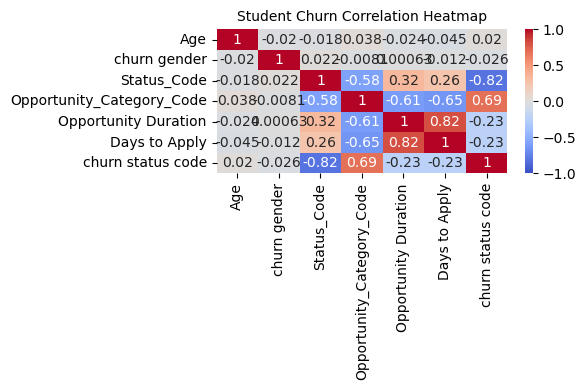

In [45]:
plt.figure(figsize=(6,4))  # smaller figure for easy screenshot
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Student Churn Correlation Heatmap", fontsize=10)
plt.tight_layout()  # ensures title and labels fit nicely
plt.show()

In [51]:
import numpy as np

cm_log = np.array([
    [156, 25],
    [36, 77]
])

In [52]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained","Churned"],
    yticklabels=["Retained","Churned"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [53]:
cm_rf = np.array([
    [178, 14],
    [22, 91]
])

In [54]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Retained","Churned"],
    yticklabels=["Retained","Churned"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [57]:
models = ["Logistic Regression", "Random Forest", "Average"]

accuracy = [79.67, 88.2, 83.935]
error = [100 - x for x in accuracy]  # complement to 100

plt.figure(figsize=(7,4))

# pastel colors
accuracy_color = "#b8c0ff"   # pastel blue/purple
error_color = "#ffd6d6"      # pastel pink

plt.barh(models, accuracy, color=accuracy_color, label="Accuracy")
plt.barh(models, error, left=accuracy, color=error_color, label="Error (100 - Accuracy)")

plt.xlabel("Percentage")
plt.title("Model Accuracy vs Error")
plt.xlim(0,100)

# show values on bars
for i,v in enumerate(accuracy):
    plt.text(v-5, i, f"{v:.2f}%", va='center', color="black")

for i,v in enumerate(error):
    plt.text(accuracy[i]+1, i, f"{v:.2f}%", va='center', color="black")

plt.legend()
plt.tight_layout()
plt.show()

In [62]:
metrics = ["Accuracy","Precision"]

rf_scores = [0.882,0.87]
log_scores = [0.7967,0.7476]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, rf_scores, width,
        label="Random Forest",
        color="blue")

plt.bar(x + width/2, log_scores, width,
        label="Logistic Regression",
        color="green")

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Model Comparison")

plt.legend()

plt.show()

In [66]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision"],
    "Random Forest": [0.882, 0.87],
    "Logistic Regression": [0.7967, 0.7476]
})

comparison_table.style\
.background_gradient(cmap="Pastel1", subset=["Random Forest","Logistic Regression"])\
.set_properties(**{'text-align': 'center'})\
.format({"Random Forest": "{:.3f}", "Logistic Regression": "{:.3f}"})

,Metric,Random Forest,Logistic Regression
0,Accuracy,0.882,0.797
1,Precision,0.870,0.748


In [67]:
import pandas as pd
import matplotlib.pyplot as plt

features = [
    "Country",
    "Current/Intended Major",
    "Days to Apply",
    "Age",
    "Opportunity Duration",
    "Opportunity Category",
    "Churn Gender"
]

importance = [0.35, 0.22, 0.18, 0.15, 0.06, 0.04, 0.03]

plt.figure(figsize=(7,4))

plt.bar(features, importance, color="#a8dadc")

plt.title("Key Drivers of Churn (Feature Importance)")

plt.xticks(rotation=40)

plt.show()

In [68]:
features_lr = [
    "Opportunity Duration",
    "Age",
    "Opportunity Category",
    "Churn Gender",
    "Current/Intended Major",
    "Days to Apply",
    "Country"
]

coefficients = [-0.25, -0.10, 0.10, 0.25, 0.60, 0.80, 1.50]

plt.figure(figsize=(7,4))

plt.barh(features_lr, coefficients, color="#bde0fe")

plt.axvline(0, color="black")  # vertical zero line

plt.title("Logistic Regression: Feature Impact (Coefficient)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()